In [ ]:
# ==========================================================
#  DATA EXPLORATION NOTEBOOK
# ==========================================================
#  OBJECTIVE:
# - Understand dataset
# - Identify patterns
# - Select target variable
# - Prepare for feature engineering

In [1]:
# ==========================================================
# STEP 1 — LOAD LIBRARIES
# ==========================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ==========================================================
# STEP 2 — LOAD DATA
# ==========================================================
df = pd.read_csv("../data/train.csv")

# View first 5 rows
df.head()

,customer_id,age,gender,country,tenure_months,monthly_spend,num_transactions,last_login_days,support_tickets,payment_method,is_active,total_spend,avg_transaction_value,target_churn,target_revenue,target_fraud
0,1502,59,Male,Germany,2,185.360890,52,18,5,PayPal,0,370.721781,6.994751,1,382.034265,0
1,2587,25,Female,US,54,108.879222,35,17,7,Card,1,5879.477977,163.318833,0,217.996705,1
2,2654,38,Female,Germany,48,221.927474,5,2,5,PayPal,1,10652.518741,1775.419790,0,208.955628,0
3,1056,48,Male,US,26,275.346433,14,26,5,Card,1,7159.007247,477.267150,0,248.913546,0
4,706,53,Male,UK,15,444.016783,95,20,0,Card,1,6660.251746,69.377622,0,768.714022,0


In [3]:
# ==========================================================
# STEP 3 — BASIC DATA INFO
# ==========================================================
#  Understand structure of dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            4000 non-null   int64  
 1   age                    4000 non-null   int64  
 2   gender                 4000 non-null   object 
 3   country                4000 non-null   object 
 4   tenure_months          4000 non-null   int64  
 5   monthly_spend          4000 non-null   float64
 6   num_transactions       4000 non-null   int64  
 7   last_login_days        4000 non-null   int64  
 8   support_tickets        4000 non-null   int64  
 9   payment_method         4000 non-null   object 
 10  is_active              4000 non-null   int64  
 11  total_spend            4000 non-null   float64
 12  avg_transaction_value  4000 non-null   float64
 13  target_churn           4000 non-null   int64  
 14  target_revenue         4000 non-null   float64
 15  targ

In [4]:
# ==========================================================
# STEP 4 — SUMMARY STATISTICS
# ==========================================================
# Understand distributions of numerical features

df.describe()

,customer_id,age,tenure_months,monthly_spend,num_transactions,last_login_days,support_tickets,is_active,total_spend,avg_transaction_value,target_churn,target_revenue,target_fraud
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2488.605000,43.617250,30.384500,260.287722,50.302750,14.871250,4.576000,0.512250,7960.363114,340.121649,0.130750,360.955385,0.171500
std,1450.904584,14.898716,16.926866,140.170997,28.807873,8.383093,2.864834,0.499912,6640.229748,780.843767,0.337169,167.073984,0.376992
min,1.000000,18.000000,1.000000,20.148671,1.000000,1.000000,0.000000,0.000000,23.481165,0.635177,0.000000,-72.269245,0.000000
25%,1234.750000,31.000000,16.000000,137.555345,25.000000,7.750000,2.000000,0.000000,2488.727165,50.914208,0.000000,233.436835,0.000000
50%,2469.500000,43.000000,30.000000,259.667856,50.000000,15.000000,5.000000,1.000000,6071.102307,135.367022,0.000000,355.167988,0.000000
75%,3758.250000,56.000000,45.000000,385.223986,75.000000,22.000000,7.000000,1.000000,11931.715821,306.158449,0.000000,482.941425,0.000000
max,5000.000000,69.000000,59.000000,499.963917,99.000000,29.000000,9.000000,1.000000,29408.316407,14598.959341,1.000000,843.213128,1.000000


In [5]:
# ==========================================================
#  STEP 5 — CHECK MISSING VALUES
# ==========================================================
#  Check if data cleaning is required

df.isnull().sum()

customer_id              0
age                      0
gender                   0
country                  0
tenure_months            0
monthly_spend            0
num_transactions         0
last_login_days          0
support_tickets          0
payment_method           0
is_active                0
total_spend              0
avg_transaction_value    0
target_churn             0
target_revenue           0
target_fraud             0
dtype: int64

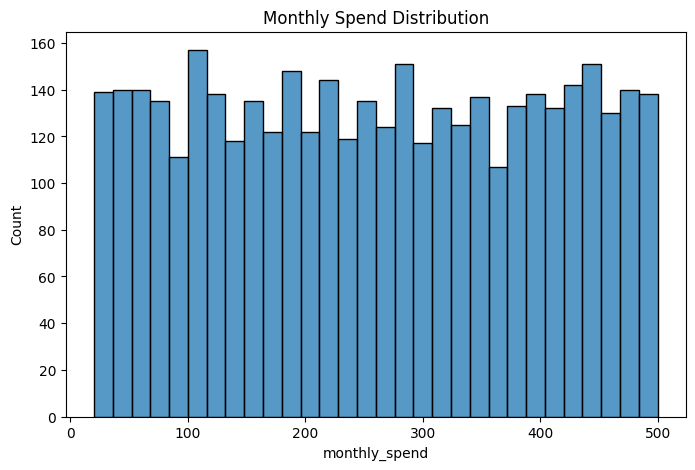

In [6]:
# ==========================================================
#  STEP 6 — DISTRIBUTION ANALYSIS
# ==========================================================
#  Understand spending behavior

plt.figure(figsize=(8,5))
sns.histplot(df["monthly_spend"], bins=30)
plt.title("Monthly Spend Distribution")
plt.show()

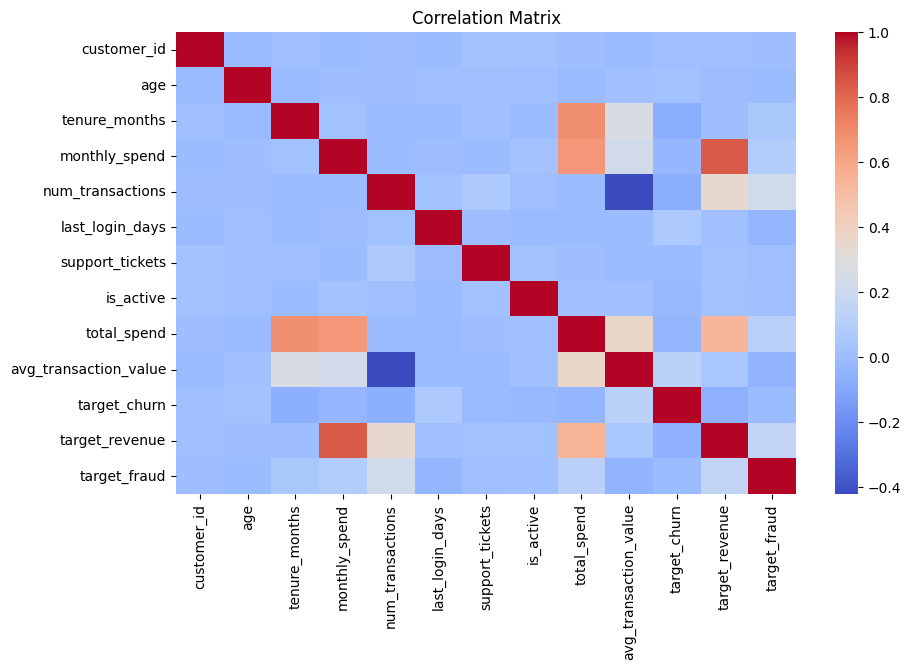

In [7]:
# ==========================================================
#  STEP 7 — CORRELATION ANALYSIS
# ==========================================================
#  Identify relationships between variables

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [8]:
# ==========================================================
#  IMPORTANT — CHOOSE YOUR TARGET
# ==========================================================
#  STUDENT TASK:
# Choose ONE target column based on your problem

# Options:
# - target_churn → Classification (0/1)
# - target_fraud → Classification (0/1)
# - target_revenue → Regression (continuous)

TARGET_COLUMN = "target_churn"   #  CHANGE THIS BASED ON YOUR TASK

In [10]:
# ==========================================================
#  STUDENT TASK 1
# ==========================================================
# Find top 3 features correlated with your target

#  Hint:
# df.corr(numeric_only=True)[TARGET_COLUMN].sort_values()

# Write your code below:

top3_features = (
    df.corr(numeric_only=True)[TARGET_COLUMN]
      .drop(TARGET_COLUMN)          # remove self-correlation
      .abs()                        # rank by strength, not direction
      .sort_values(ascending=False)
      .head(3)
)

print("Top 3 features correlated with", TARGET_COLUMN)
print(top3_features)

Top 3 features correlated with target_churn
avg_transaction_value    0.125150
num_transactions         0.068516
tenure_months            0.063186
Name: target_churn, dtype: float64


C:\Users\harih\AppData\Local\Temp\ipykernel_8156\2653759208.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


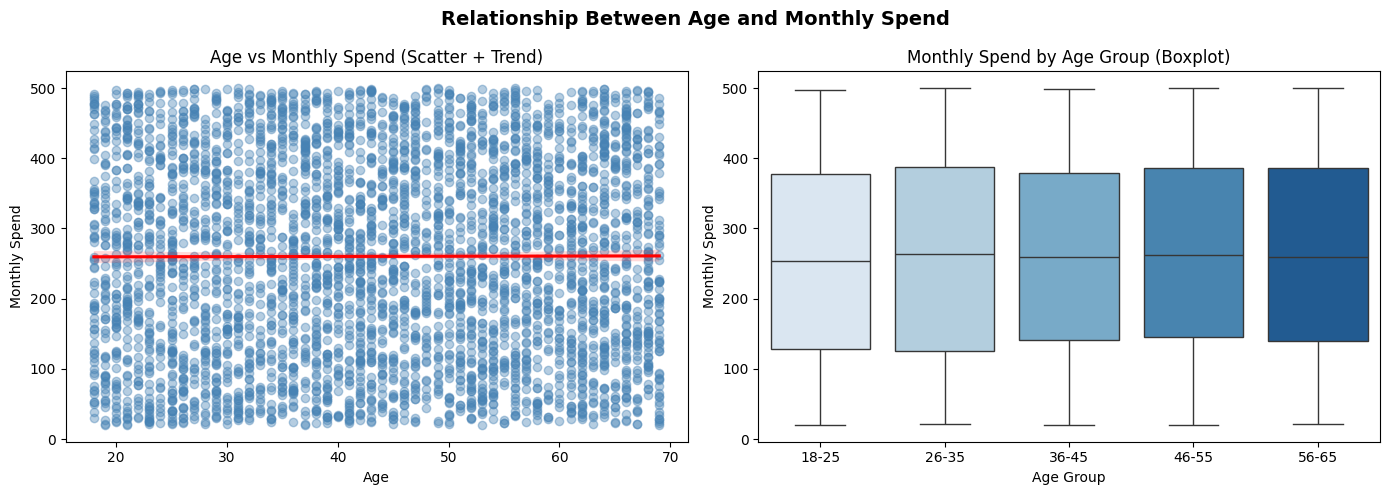

In [11]:
# ==========================================================
#  STUDENT TASK 2
# ==========================================================
# Analyze relationship between age and monthly_spend

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Scatterplot with regression line ---
sns.regplot(
    data=df,
    x="age",
    y="monthly_spend",
    ax=axes[0],
    scatter_kws={"alpha": 0.4, "color": "steelblue"},
    line_kws={"color": "red"}
)
axes[0].set_title("Age vs Monthly Spend (Scatter + Trend)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Monthly Spend")

# --- Plot 2: Boxplot by age group ---
df["age_group"] = pd.cut(df["age"], bins=[18, 25, 35, 45, 55, 65],
                          labels=["18-25", "26-35", "36-45", "46-55", "56-65"])

sns.boxplot(
    data=df,
    x="age_group",
    y="monthly_spend",
    ax=axes[1],
    palette="Blues"
)
axes[1].set_title("Monthly Spend by Age Group (Boxplot)")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Monthly Spend")

plt.suptitle("Relationship Between Age and Monthly Spend", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
# ==========================================================
#  STUDENT TASK 3
# ==========================================================
# Which country has highest churn rate?

#  Hint:
# groupby + mean

# Example:
# df.groupby("country")[TARGET_COLUMN].mean()

# Write your code below:

churn_by_country = (
    df.groupby("country")[TARGET_COLUMN]
      .mean()
      .mul(100)                        # convert to percentage
      .round(2)
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={TARGET_COLUMN: "churn_rate_%"})
)

print(churn_by_country)
print(f"\n✅ Highest churn country: {churn_by_country.iloc[0]['country']} "
      f"({churn_by_country.iloc[0]['churn_rate_%']}%)")

   country  churn_rate_%
0    India         14.29
1  Germany         13.64
2       US         12.32
3       UK         12.15

✅ Highest churn country: India (14.29%)
